In [1]:
from pathlib import Path
import os

import pandas as pd
from dotenv import load_dotenv
from sqlalchemy import URL, create_engine, text

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

PROJECT_ROOT = Path.cwd().parent
ENV_PATH = PROJECT_ROOT / ".env"

load_dotenv(ENV_PATH)

db_url = URL.create(
    drivername="postgresql+psycopg",
    username=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD"),
    host=os.getenv("DB_HOST"),
    port=int(os.getenv("DB_PORT")),
    database=os.getenv("DB_NAME"),
)

engine = create_engine(db_url)

geo_postings = pd.read_sql_query(
    sql=text(
        """
        SELECT
            job_id,
            job_title_short,
            job_location,
            job_country,
            job_work_from_home,
            search_location
        FROM data_jobs.job_postings_fact
        """
    ),
    con=engine,
)

print(
    f"Loaded geographic analysis DataFrame: "
    f"{geo_postings.shape[0]:,} rows × {geo_postings.shape[1]} columns"
)

display(geo_postings.head())

Loaded geographic analysis DataFrame: 478,895 rows × 6 columns


,job_id,job_title_short,job_location,job_country,job_work_from_home,search_location
0,42851,Data Engineer,"Bezons, France",France,False,France
1,42852,Data Engineer,Anywhere,Portugal,True,Portugal
2,42853,Data Engineer,Anywhere,Philippines,True,Philippines
3,42854,Data Engineer,"Stockholm, Sweden",Sweden,False,Sweden
4,42855,Data Analyst,"Glasgow, UK",United Kingdom,False,United Kingdom


In [2]:
geo_postings["job_location_clean"] = (
    geo_postings["job_location"]
    .fillna("")
    .str.strip()
)

geo_postings["location_class"] = "Other raw location"

geo_postings.loc[
    geo_postings["job_location"].isna()
    | geo_postings["job_location_clean"].eq(""),
    "location_class",
] = "Missing location"

geo_postings.loc[
    geo_postings["job_location_clean"].str.casefold().eq("anywhere"),
    "location_class",
] = "Anywhere"

geo_postings.loc[
    geo_postings["job_location_clean"].str.contains(
        "remote",
        case=False,
        regex=False,
    )
    & ~geo_postings["job_location_clean"].str.casefold().eq("anywhere"),
    "location_class",
] = "Contains remote"

geo_postings.loc[
    geo_postings["job_work_from_home"]
    & ~geo_postings["location_class"].isin(
        [
            "Anywhere",
            "Contains remote",
            "Missing location",
        ]
    ),
    "location_class",
] = "Work-from-home flag only"

location_class_profile = (
    geo_postings
    .groupby(
        "location_class",
        as_index=False,
    )
    .agg(
        posting_count=("job_id", "nunique"),
        unique_raw_locations=("job_location_clean", "nunique"),
    )
)

location_class_profile["posting_share_pct"] = (
    location_class_profile["posting_count"]
    / len(geo_postings)
    * 100
).round(2)

location_class_order = [
    "Anywhere",
    "Contains remote",
    "Work-from-home flag only",
    "Other raw location",
    "Missing location",
]

location_class_profile["location_class"] = pd.Categorical(
    location_class_profile["location_class"],
    categories=location_class_order,
    ordered=True,
)

location_class_profile = (
    location_class_profile
    .sort_values("location_class")
    .reset_index(drop=True)
)

display(location_class_profile)

,location_class,posting_count,unique_raw_locations,posting_share_pct
0,Anywhere,63090,1,13.17
1,Contains remote,621,3,0.13
2,Other raw location,413811,16356,86.41
3,Missing location,1373,1,0.29


In [3]:
geo_postings["potentially_location_independent"] = (
    geo_postings["job_work_from_home"]
    | geo_postings["location_class"].isin(
        [
            "Anywhere",
            "Contains remote",
        ]
    )
)

geo_postings["potentially_location_independent_reason"] = (
    "Not flagged"
)

geo_postings.loc[
    geo_postings["location_class"].eq("Anywhere"),
    "potentially_location_independent_reason",
] = "Anywhere location"

geo_postings.loc[
    geo_postings["location_class"].eq("Contains remote"),
    "potentially_location_independent_reason",
] = "Remote text in location"

geo_postings.loc[
    geo_postings["job_work_from_home"]
    & ~geo_postings["location_class"].isin(
        [
            "Anywhere",
            "Contains remote",
        ]
    ),
    "potentially_location_independent_reason",
] = "Work-from-home flag"

geo_postings.loc[
    geo_postings["job_work_from_home"]
    & geo_postings["location_class"].eq("Anywhere"),
    "potentially_location_independent_reason",
] = "Anywhere location and work-from-home flag"

geo_postings.loc[
    geo_postings["job_work_from_home"]
    & geo_postings["location_class"].eq("Contains remote"),
    "potentially_location_independent_reason",
] = "Remote text in location and work-from-home flag"

remote_accessibility_summary = pd.DataFrame(
    {
        "metric": [
            "total_postings",
            "postings_with_work_from_home_flag",
            "postings_with_work_from_home_flag_pct",
            "anywhere_location_postings",
            "anywhere_location_postings_pct",
            "locations_containing_remote_postings",
            "locations_containing_remote_postings_pct",
            "potentially_location_independent_postings",
            "potentially_location_independent_postings_pct",
        ],
        "value": [
            len(geo_postings),
            geo_postings["job_work_from_home"].sum(),
            round(
                geo_postings["job_work_from_home"].mean() * 100,
                2,
            ),
            geo_postings["location_class"].eq("Anywhere").sum(),
            round(
                geo_postings["location_class"].eq("Anywhere").mean()
                * 100,
                2,
            ),
            geo_postings["location_class"].eq("Contains remote").sum(),
            round(
                geo_postings["location_class"].eq(
                    "Contains remote"
                ).mean()
                * 100,
                2,
            ),
            geo_postings["potentially_location_independent"].sum(),
            round(
                geo_postings[
                    "potentially_location_independent"
                ].mean()
                * 100,
                2,
            ),
        ],
    }
)

remote_reason_profile = (
    geo_postings
    .groupby(
        "potentially_location_independent_reason",
        as_index=False,
    )
    .agg(
        posting_count=("job_id", "nunique"),
    )
)

remote_reason_profile["posting_share_pct"] = (
    remote_reason_profile["posting_count"]
    / len(geo_postings)
    * 100
).round(2)

remote_reason_profile = remote_reason_profile.sort_values(
    by="posting_count",
    ascending=False,
).reset_index(drop=True)

display(remote_accessibility_summary)

display(remote_reason_profile)

,metric,value
0,total_postings,"478,895.00"
1,postings_with_work_from_home_flag,"62,995.00"
2,postings_with_work_from_home_flag_pct,13.15
3,anywhere_location_postings,"63,090.00"
4,anywhere_location_postings_pct,13.17
5,locations_containing_remote_postings,621.00
6,locations_containing_remote_postings_pct,0.13
7,potentially_location_independent_postings,"63,711.00"
8,potentially_location_independent_postings_pct,13.30


,potentially_location_independent_reason,posting_count,posting_share_pct
0,Not flagged,415184,86.70
1,Anywhere location and work-from-home flag,62995,13.15
2,Remote text in location,621,0.13
3,Anywhere location,95,0.02


In [4]:
country_values = (
    geo_postings["job_country"]
    .dropna()
    .astype(str)
    .str.strip()
    .str.casefold()
    .unique()
    .tolist()
)

non_city_location_values = {
    "anywhere",
    "remote",
    "hybrid",
    "worldwide",
    "global",
    "multiple locations",
    "various locations",
    "united states",
    "united kingdom",
    "united arab emirates",
    "hong kong",
    "singapore",
    "taiwan",
}

non_city_location_values.update(country_values)

geo_postings["city_candidate"] = (
    geo_postings["job_location_clean"]
    .str.split(",", n=1)
    .str[0]
    .str.strip()
)

geo_postings["city_candidate_normalized"] = (
    geo_postings["city_candidate"]
    .str.casefold()
)

geo_postings["city_candidate_valid"] = (
    geo_postings["city_candidate"].notna()
    & geo_postings["city_candidate"].ne("")
    & ~geo_postings["city_candidate_normalized"].isin(
        non_city_location_values
    )
    & ~geo_postings["city_candidate"].str.contains(
        "remote",
        case=False,
        regex=False,
        na=False,
    )
    & ~geo_postings["city_candidate"].str.contains(
        "hybrid",
        case=False,
        regex=False,
        na=False,
    )
)

geo_postings["city_candidate"] = geo_postings[
    "city_candidate"
].where(
    geo_postings["city_candidate_valid"],
    pd.NA,
)

city_parse_summary = pd.DataFrame(
    {
        "metric": [
            "total_postings",
            "postings_with_non_missing_raw_location",
            "postings_with_valid_city_candidate",
            "postings_with_valid_city_candidate_pct",
            "postings_excluded_from_city_candidate",
            "unique_valid_city_candidates",
        ],
        "value": [
            len(geo_postings),
            geo_postings["job_location"].notna().sum(),
            geo_postings["city_candidate"].notna().sum(),
            round(
                geo_postings["city_candidate"].notna().mean()
                * 100,
                2,
            ),
            geo_postings["city_candidate"].isna().sum(),
            geo_postings["city_candidate"].nunique(dropna=True),
        ],
    }
)

top_city_candidates = (
    geo_postings
    .dropna(subset=["city_candidate"])
    .groupby(
        [
            "city_candidate",
            "job_country",
        ],
        as_index=False,
    )
    .agg(
        posting_count=("job_id", "nunique"),
        work_from_home_postings=(
            "job_work_from_home",
            "sum",
        ),
        potentially_location_independent_postings=(
            "potentially_location_independent",
            "sum",
        ),
        unique_job_roles=("job_title_short", "nunique"),
    )
)

top_city_candidates["work_from_home_share_pct"] = (
    top_city_candidates["work_from_home_postings"]
    / top_city_candidates["posting_count"]
    * 100
).round(2)

top_city_candidates[
    "potentially_location_independent_share_pct"
] = (
    top_city_candidates[
        "potentially_location_independent_postings"
    ]
    / top_city_candidates["posting_count"]
    * 100
).round(2)

top_city_candidates = top_city_candidates.sort_values(
    by="posting_count",
    ascending=False,
).reset_index(drop=True)

display(city_parse_summary)

display(top_city_candidates.head(50))

,metric,value
0,total_postings,"478,895.00"
1,postings_with_non_missing_raw_location,"477,522.00"
2,postings_with_valid_city_candidate,"342,386.00"
3,postings_with_valid_city_candidate_pct,71.50
4,postings_excluded_from_city_candidate,"136,509.00"
5,unique_valid_city_candidates,"12,914.00"


,city_candidate,job_country,posting_count,work_from_home_postings,potentially_location_independent_postings,unique_job_roles,work_from_home_share_pct,potentially_location_independent_share_pct
0,New York,United States,8526,0,0,10,0.00,0.00
1,London,United Kingdom,6299,0,0,10,0.00,0.00
2,Bengaluru,India,5877,0,0,10,0.00,0.00
3,Paris,France,5836,0,0,10,0.00,0.00
4,Hyderabad,India,4956,0,0,10,0.00,0.00
5,Madrid,Spain,4865,0,0,10,0.00,0.00
6,Amsterdam,Netherlands,3595,0,0,10,0.00,0.00
7,Atlanta,United States,3155,0,0,10,0.00,0.00
8,Chicago,United States,2965,0,0,10,0.00,0.00
9,Lisbon,Portugal,2804,0,0,10,0.00,0.00


In [5]:
MIN_CITY_POSTINGS = 100

city_market_summary = (
    top_city_candidates
    .loc[
        top_city_candidates["posting_count"] >= MIN_CITY_POSTINGS
    ]
    .copy()
)

city_market_summary = city_market_summary.sort_values(
    by=[
        "posting_count",
        "city_candidate",
        "job_country",
    ],
    ascending=[
        False,
        True,
        True,
    ],
).reset_index(drop=True)

city_market_summary_summary = pd.DataFrame(
    {
        "metric": [
            "minimum_postings_per_city_country_group",
            "city_country_groups_before_threshold",
            "city_country_groups_after_threshold",
            "postings_covered_by_city_summary",
            "share_of_all_postings_covered_pct",
        ],
        "value": [
            MIN_CITY_POSTINGS,
            len(top_city_candidates),
            len(city_market_summary),
            city_market_summary["posting_count"].sum(),
            round(
                city_market_summary["posting_count"].sum()
                / len(geo_postings)
                * 100,
                2,
            ),
        ],
    }
)

display(city_market_summary_summary)

display(city_market_summary.head(50))

,metric,value
0,minimum_postings_per_city_country_group,100.00
1,city_country_groups_before_threshold,"14,144.00"
2,city_country_groups_after_threshold,483.00
3,postings_covered_by_city_summary,"248,472.00"
4,share_of_all_postings_covered_pct,51.88


,city_candidate,job_country,posting_count,work_from_home_postings,potentially_location_independent_postings,unique_job_roles,work_from_home_share_pct,potentially_location_independent_share_pct
0,New York,United States,8526,0,0,10,0.00,0.00
1,London,United Kingdom,6299,0,0,10,0.00,0.00
2,Bengaluru,India,5877,0,0,10,0.00,0.00
3,Paris,France,5836,0,0,10,0.00,0.00
4,Hyderabad,India,4956,0,0,10,0.00,0.00
5,Madrid,Spain,4865,0,0,10,0.00,0.00
6,Amsterdam,Netherlands,3595,0,0,10,0.00,0.00
7,Atlanta,United States,3155,0,0,10,0.00,0.00
8,Chicago,United States,2965,0,0,10,0.00,0.00
9,Lisbon,Portugal,2804,0,0,10,0.00,0.00


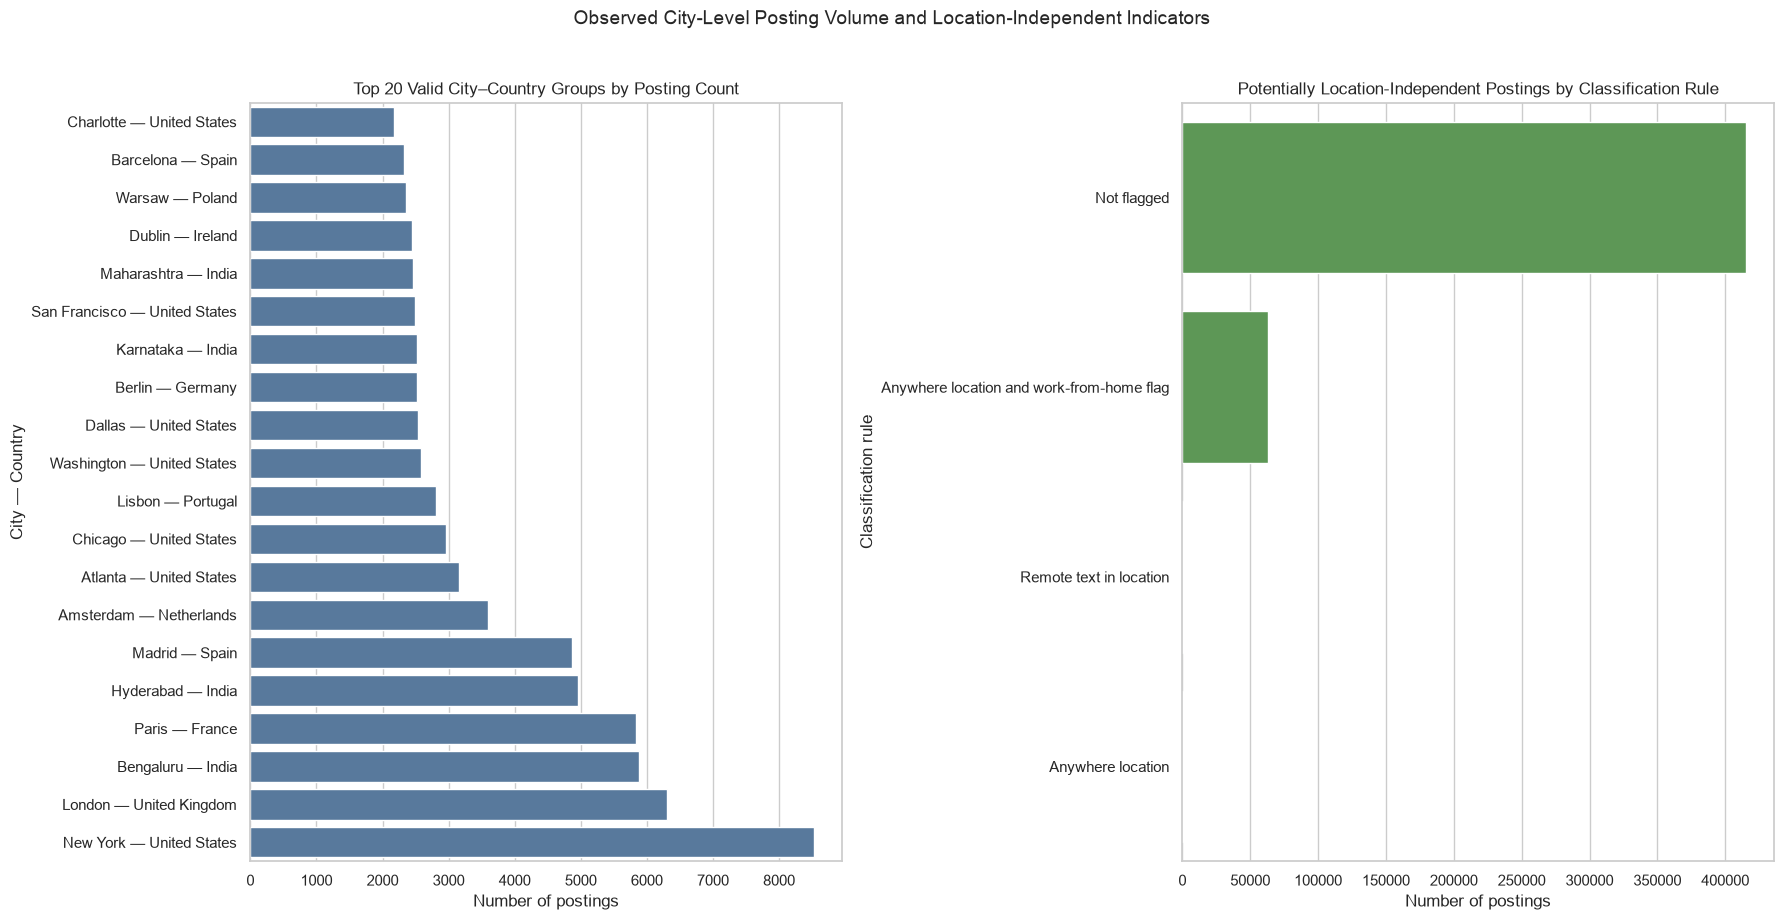

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

TOP_N_CITIES = 20

top_cities_plot = (
    city_market_summary
    .head(TOP_N_CITIES)
    .sort_values(
        by="posting_count",
        ascending=True,
    )
    .copy()
)

top_cities_plot["city_country_label"] = (
    top_cities_plot["city_candidate"]
    + " — "
    + top_cities_plot["job_country"].fillna("Unknown country")
)

remote_kpis_plot = remote_reason_profile.copy()

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(18, 9),
)

sns.barplot(
    data=top_cities_plot,
    x="posting_count",
    y="city_country_label",
    ax=axes[0],
    color="#4C78A8",
)

axes[0].set_title(
    f"Top {TOP_N_CITIES} Valid City–Country Groups by Posting Count"
)
axes[0].set_xlabel("Number of postings")
axes[0].set_ylabel("City — Country")

sns.barplot(
    data=remote_kpis_plot,
    x="posting_count",
    y="potentially_location_independent_reason",
    ax=axes[1],
    color="#54A24B",
)

axes[1].set_title(
    "Potentially Location-Independent Postings by Classification Rule"
)
axes[1].set_xlabel("Number of postings")
axes[1].set_ylabel("Classification rule")

fig.suptitle(
    "Observed City-Level Posting Volume and Location-Independent Indicators",
    fontsize=14,
    y=1.02,
)

plt.tight_layout()
plt.show()

In [7]:
geographic_analysis_summary = {
    "analysis_population": {
        "total_postings": int(len(geo_postings)),
        "non_missing_job_location_postings": int(
            geo_postings["job_location"].notna().sum()
        ),
        "unique_raw_non_missing_locations": int(
            geo_postings["job_location"].nunique(dropna=True)
        ),
    },
    "location_classification": (
        location_class_profile
        .to_dict(orient="records")
    ),
    "remote_accessibility": {
        "work_from_home_flag_postings": int(
            geo_postings["job_work_from_home"].sum()
        ),
        "work_from_home_flag_pct": float(
            round(
                geo_postings["job_work_from_home"].mean() * 100,
                2,
            )
        ),
        "anywhere_location_postings": int(
            geo_postings["location_class"].eq("Anywhere").sum()
        ),
        "locations_containing_remote_postings": int(
            geo_postings["location_class"]
            .eq("Contains remote")
            .sum()
        ),
        "potentially_location_independent_postings": int(
            geo_postings["potentially_location_independent"].sum()
        ),
        "potentially_location_independent_pct": float(
            round(
                geo_postings[
                    "potentially_location_independent"
                ].mean()
                * 100,
                2,
            )
        ),
    },
    "city_candidate_parsing": {
        "parsing_rule": (
            "First text segment before the first comma, excluding values "
            "equal to a known country, remote-related labels, and other "
            "non-city location labels."
        ),
        "postings_with_valid_city_candidate": int(
            geo_postings["city_candidate"].notna().sum()
        ),
        "postings_with_valid_city_candidate_pct": float(
            round(
                geo_postings["city_candidate"].notna().mean()
                * 100,
                2,
            )
        ),
        "unique_valid_city_candidates": int(
            geo_postings["city_candidate"].nunique(dropna=True)
        ),
        "minimum_postings_per_city_country_group": int(
            MIN_CITY_POSTINGS
        ),
        "city_country_groups_in_summary": int(
            len(city_market_summary)
        ),
    },
    "top_20_city_country_groups": (
        city_market_summary
        .head(20)
        .to_dict(orient="records")
    ),
    "map_status": {
        "generated": False,
        "reason": (
            "The source dataset does not include validated coordinates. "
            "Automatic geocoding and map generation were deferred to avoid "
            "presenting unvalidated geographic matches."
        ),
    },
    "limitations": [
        (
            "City candidates are parsed from raw text and are not geocoded "
            "or manually validated."
        ),
        (
            "A work-from-home flag, 'Anywhere', or remote-related text "
            "does not guarantee legal cross-border eligibility."
        ),
        (
            "Potentially location-independent is a broad classification rule, "
            "not proof of worldwide remote eligibility."
        ),
        (
            "City-level results describe observed postings in the dataset "
            "and are not a complete census of labour-market demand."
        ),
    ],
}

geographic_summary_preview = pd.DataFrame(
    {
        "metric": [
            "total_postings",
            "raw_non_missing_locations",
            "unique_raw_locations",
            "potentially_location_independent_postings",
            "potentially_location_independent_pct",
            "postings_with_valid_city_candidate",
            "valid_city_candidate_pct",
            "city_country_groups_after_threshold",
            "map_generated",
        ],
        "value": [
            geographic_analysis_summary[
                "analysis_population"
            ]["total_postings"],
            geographic_analysis_summary[
                "analysis_population"
            ]["non_missing_job_location_postings"],
            geographic_analysis_summary[
                "analysis_population"
            ]["unique_raw_non_missing_locations"],
            geographic_analysis_summary[
                "remote_accessibility"
            ]["potentially_location_independent_postings"],
            geographic_analysis_summary[
                "remote_accessibility"
            ]["potentially_location_independent_pct"],
            geographic_analysis_summary[
                "city_candidate_parsing"
            ]["postings_with_valid_city_candidate"],
            geographic_analysis_summary[
                "city_candidate_parsing"
            ]["postings_with_valid_city_candidate_pct"],
            geographic_analysis_summary[
                "city_candidate_parsing"
            ]["city_country_groups_in_summary"],
            geographic_analysis_summary["map_status"]["generated"],
        ],
    }
)

display(geographic_summary_preview)

,metric,value
0,total_postings,478895
1,raw_non_missing_locations,477522
2,unique_raw_locations,16360
3,potentially_location_independent_postings,63711
4,potentially_location_independent_pct,13.30
5,postings_with_valid_city_candidate,342386
6,valid_city_candidate_pct,71.50
7,city_country_groups_after_threshold,483
8,map_generated,False
